Aquesta pràctica integra l'ús de Python amb les llibreries Pandas, Matplotlib, Seaborn o Plotly, així com la seva integració amb Power BI. Treballaràs tot el procés des de la connexió a MySQL, la creació de visualitzacions avançades en Python i finalment la incorporació d'aquestes visualitzacions a un informe dinàmic a Power BI.


### **Nivell 1**

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [13]:
import mysql.connector
from mysql.connector import Error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import getpass

In [14]:
host = input("Host (ejemplo: 'localhost'): ")
user = input("Usuario: ")
password = getpass.getpass("Password: ")
database = input("Base de datos: ")

conn = mysql.connector.connect(
    host=host,
    user=user,
    password=password,
    database=database
)

In [15]:
query = "SELECT * FROM companies"
df_companies = pd.read_sql(query, conn)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_72539/1474432342.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_companies = pd.read_sql(query, conn)


In [16]:
query = "SELECT * FROM credit_cards"
df_credit_cards = pd.read_sql(query, conn)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_72539/262380319.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_credit_cards = pd.read_sql(query, conn)


In [17]:
query = "SELECT * FROM products"
df_products = pd.read_sql(query, conn)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_72539/1296195807.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql(query, conn)


In [18]:
query = "SELECT * FROM status_cards"
df_status_cards = pd.read_sql(query, conn)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_72539/1911008225.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_status_cards = pd.read_sql(query, conn)


In [19]:
query = "SELECT * FROM transactions_products"
df_transactions_products = pd.read_sql(query, conn)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_72539/2180151217.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transactions_products = pd.read_sql(query, conn)


In [20]:
query = "SELECT * FROM transactions"
df_transactions = pd.read_sql(query, conn)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_72539/506465238.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transactions = pd.read_sql(query, conn)


In [21]:
query = "SELECT * FROM users"
df_users = pd.read_sql(query, conn)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_72539/355473462.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users = pd.read_sql(query, conn)


    Pequeña visualización y revisión de las tablas (dataframes):

In [22]:
df_companies.head()

,id,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site\r
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9\r
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars\r
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110\r
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings\r


In [23]:
df_companies['website'] = df_companies['website'].str.replace('\r', '', regex=False)
df_companies.head()

,id,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings


In [24]:
df_credit_cards.head()

,id,user_id,iban,pan,pin,cvv,track1,track2,expiring_date
0,CcS-4857,276,XX4857591835292505850771,2314242385113924,1819,467,%B2314242385113924^LWCBUDLWCBUD^22060000000000...,%B2314242385113924=2410101518363164?,2025-09-27
1,CcS-4858,277,XX8581768137002436094025,6582720299715533,3964,817,%B6582720299715533^TIQMVITIQMVI^24040000000000...,%B6582720299715533=2411101104546272?,2028-12-28
2,CcS-4859,278,XX7826930491423553609370,8861684536289642,4983,277,%B8861684536289642^COFBGDCOFBGD^28020000000000...,%B8861684536289642=2502101761665371?,2026-11-26
3,CcS-4860,279,XX5559590368835304645299,2481155515498459,6876,661,%B2481155515498459^TIUJTUTIUJTU^31040000000000...,%B2481155515498459=2602101514414395?,2027-07-27
4,CcS-4861,280,XX2035182877195191627307,1308930301149557,5710,398,%B1308930301149557^HPOBNZHPOBNZ^33010000000000...,%B1308930301149557=2805101751305028?,2026-04-25


In [25]:
df_products.head()

,id,product_name,price_usd,colour,weight,warehouse_id
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4
1,2,Tarly Stark,9.24,#919191,2.0,WH-3
2,3,duel tourney Lannister,171.13,#d8d8d8,1.5,WH-2
3,4,warden south duel,71.89,#111111,3.0,WH-1
4,5,skywalker ewok,171.22,#dbdbdb,3.2,WH-0


In [26]:
df_status_cards.head()

,card_id,status
0,CcS-4857,active
1,CcS-4858,active
2,CcS-4859,active
3,CcS-4860,active
4,CcS-4861,active


In [27]:
df_transactions.head()

,id,card_id,company_id,timestamp,amount,declined,product_ids,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"[16,26,97,87]",4713,46.1999,1.43554
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"[66,69,87]",438,41.5972,12.22180
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"[30,11,16,81]",2118,29.7573,-95.37960
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,[72],2115,53.5489,-113.50300
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,[18],3025,52.2084,5.69081


In [28]:
df_transactions_products.head()

,transaction_id,product_id
0,001A60EA-DC9C-4E5A-9460-6628B100E7E1,1
1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48,1
2,00342381-503D-422D-85AB-F2D4FFAAD4C7,1
3,004C0A80-E537-46D8-BE44-343D2176DF15,1
4,004D1DB5-B2CB-4460-98B6-31C42CA96E5F,1


In [29]:
df_users.head()

,id,name,surname,phone,email,birth_date,country,city,postal_code,address,continent
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,America
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,1992-08-23,United States,Philadelphia,19101,903 Sit Ave,America
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,1998-04-29,United States,Houston,77001,736-2063 Tellus St.,America
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,1989-02-18,United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,America
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,1998-09-26,United States,Philadelphia,19101,341-2821 Ultrices Av.,America


2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

Una variable numèrica.

Dues variables numèriques.

Una variable categòrica.

Una variable categòrica i una numèrica.

Dues variables categòriques.

Tres variables combinades.

Crea un Pairplot.

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from utils import calcular_edat #utilzo una funcion creada y guardada previamente en sprint 10

In [32]:
df_users['age'] = df_users['birth_date'].apply(calcular_edat)

In [33]:
df_users[['birth_date','age']].head()

,birth_date,age
0,1985-11-17,40
1,1992-08-23,33
2,1998-04-29,27
3,1989-02-18,37
4,1998-09-26,27


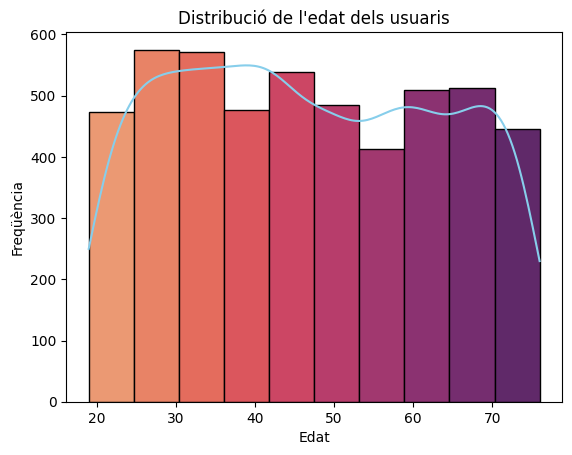

In [34]:
#Una variable numèrica - Edat dels Usuaris
cm=sns.color_palette("flare",10)

hp=sns.histplot(df_users['age'], kde=True, bins=10, color='skyblue') #kde: curva de estiamción
plt.title("Distribució de l'edat dels usuaris")
plt.xlabel("Edat")
plt.ylabel("Freqüència")

for bin_,i in zip(hp.patches,cm):
    bin_.set_facecolor(i)

plt.show()

Interpretació: La edat es força bé distribuida entre els 18 i els 75 años aproximadament. Hi ha una lleugera concentració entre els 25-50 años, aquest podría ser el segment principal.

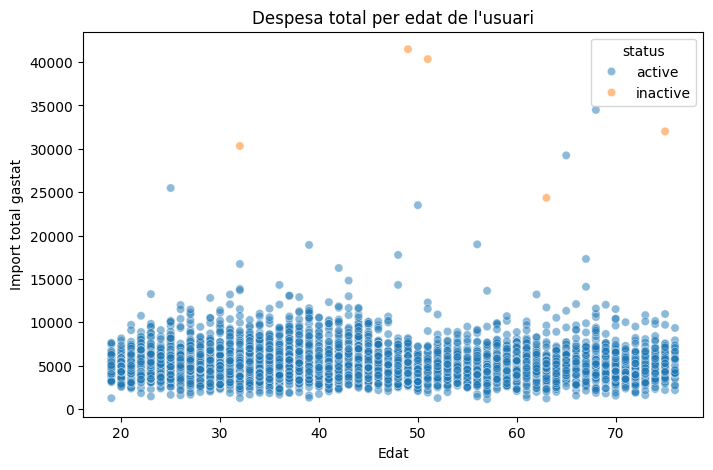

In [35]:
#Dues variables númeriques - Despesa total per edat de l'usuari
df_user_spending = df_transactions.merge(
    df_users[['id','age']],
    left_on='user_id',
    right_on='id',
    how='left'
)

df_user_spending = df_user_spending.merge( #Opcional: añado status para ubicar donde se encuentran el gasto de las inactivas
    df_status_cards[['card_id','status']],
    on='card_id',
    how='left'
)

df_user_spending = df_user_spending.groupby(['user_id','age','status'])['amount'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='amount',
    hue='status',
    data=df_user_spending,
    alpha=0.5
) #alpha es la densitat dels punts

plt.title("Despesa total per edat de l'usuari")
plt.xlabel("Edat")
plt.ylabel("Import total gastat")
plt.show()

Interpetació: No s'observa una relació clara entre l'edat i la despesa. Observem molta dispersió, és a dir, usuaris de qualsevol edat tenen una despesa similar. Existeixen forts outliers, entre aquests estan les targetes inactives

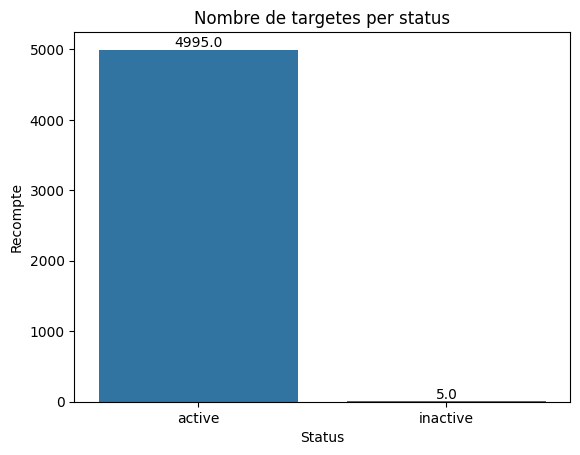

In [36]:
#Una variable categorica - Nombre de targetes per status
ax = sns.countplot(x='status', data=df_status_cards) #ax convención para referirse al eje donde se dibuja el grafico
plt.title("Nombre de targetes per status")
plt.xlabel("Status")
plt.ylabel("Recompte")

# Añadir etiquetas encima de cada barra
for barra in ax.patches:
    height = barra.get_height() #en un coumtplot la altura es el conteo de elementos
    ax.annotate(f'{height}', (barra.get_x() + barra.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10) #covertimos a texto y le damos una posición sobre las barras

plt.show()

Interpretació: El 99,9% de les tarjetes estan actives.

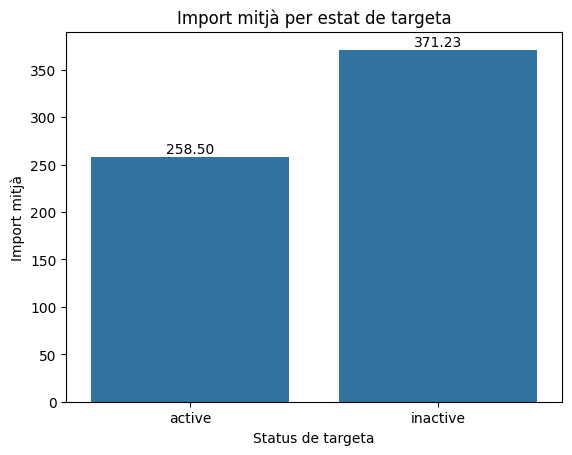

In [37]:
#Una variable categorica i una númerica - Import mitjà per estat de tarjeta
df_status_amount = df_transactions.merge(
    df_status_cards, 
    left_on='card_id', 
    right_on='card_id', 
    how='left'
)

df_status_amount = df_status_amount.groupby('status')['amount'].mean().reset_index()

ax2 = sns.barplot(x='status', y='amount', data=df_status_amount)
plt.title("Import mitjà per estat de targeta")
plt.xlabel("Status de targeta")
plt.ylabel("Import mitjà")

for barra in ax2.patches:
    height = barra.get_height()
    ax2.annotate(f'{height:.2f}', (barra.get_x() + barra.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.show()

Interpretació: Tot i que les targetes 5 tarjetes inactives mostren un import mitjà superior, el nombre reduït de registres fa que aquesta comparació no sigui fiable pertot.

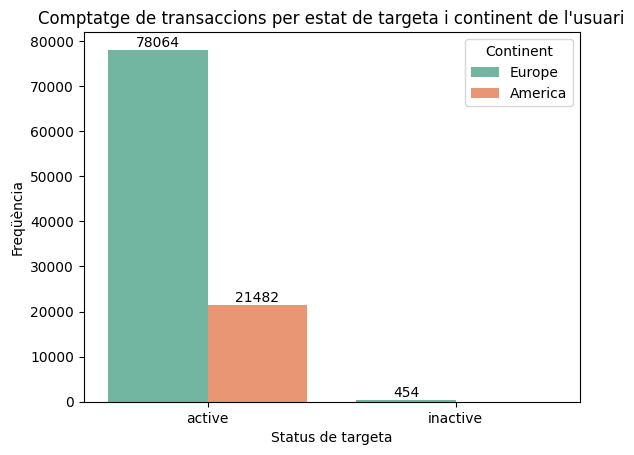

In [45]:
#Dues variables categòriques - Estat de tarjeta i continent de usuari
df_merge_t_continent = df_transactions.merge(
    df_users[['id','continent']], 
    left_on='user_id', 
    right_on='id', 
    how='left'
)

df_merge_t_continent_status = df_merge_t_continent.merge(
    df_status_cards,
    on='card_id',
    how='left'
)

df_merge_final=df_merge_t_continent_status.rename(columns={'id_x':'id_transaction'}).drop(columns=['id_y'])

ax3 = sns.countplot(x='status', hue='continent', data=df_merge_final, palette='Set2')
plt.title("Comptatge de transaccions per estat de targeta i continent de l'usuari")
plt.xlabel("Status de targeta")
plt.ylabel("Freqüència")
plt.legend(title="Continent")

for barra in ax3.patches:
    height = barra.get_height()
    if height > 0:
        ax3.annotate(f'{int(height)}', (barra.get_x() + barra.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10)

plt.show()

Interpretació: Europa té molts més usuaris que America. En ambdos continents: La majoria de targetes estan actives i les inactives residuals es troben en Europa.

In [46]:
df_merge_final #comprovación rapida de que hay en el df merged

,id_transaction,card_id,company_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,continent,status
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"[16,26,97,87]",4713,46.1999,1.43554,Europe,active
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"[66,69,87]",438,41.5972,12.22180,Europe,active
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"[30,11,16,81]",2118,29.7573,-95.37960,America,active
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,[72],2115,53.5489,-113.50300,America,active
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,[18],3025,52.2084,5.69081,Europe,active
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,2022-12-17 20:57:55,247.39,0,"[20,42,54,46]",429,52.5223,13.40490,Europe,active
99996,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,2024-05-13 03:42:03,349.13,0,"[30,87,5,66]",3074,39.0271,-8.10523,Europe,active
99997,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,234.22,0,"[16,49]",1008,59.3327,18.07530,Europe,active
99998,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,148.91,0,[18],680,52.0635,4.30862,Europe,active


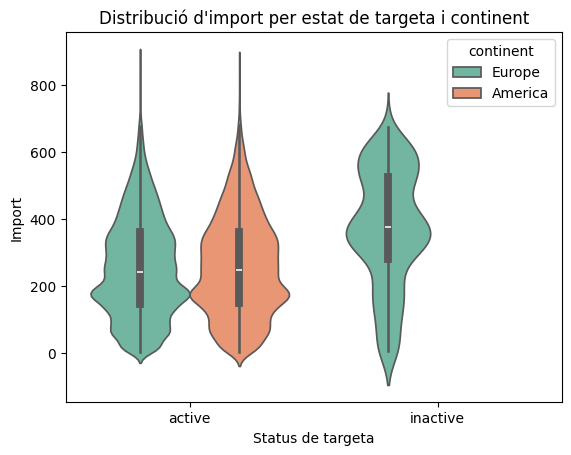

In [47]:
#Tres variables combinades: import per estat i continent
sns.violinplot(
    x='status',
    y='amount',
    hue='continent',
    data=df_merge_final,
    palette='Set2'
)

plt.title("Distribució d'import per estat de targeta i continent")
plt.xlabel("Status de targeta")
plt.ylabel("Import")
plt.show()

#hacerlo con plotly express parav poder ver los datos de forma dinamica

Interpretació: Les distribucions de despesa son força similars entre continents. Les actives tenen menor dispersió i les inactives semblen tenir valors més alts, però son poques dades, no és fiable. En conclusió, no s’observen diferències clares entre continents en la distribució de la despesa.

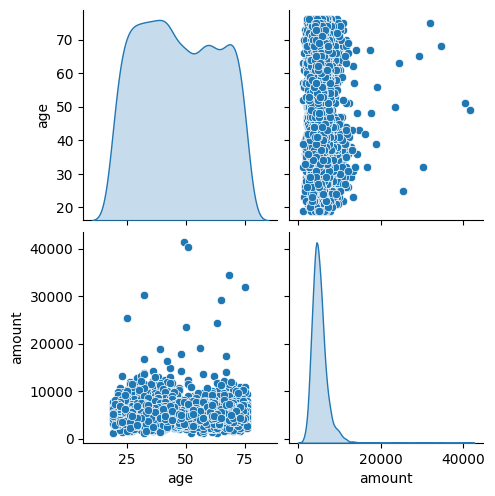

In [ ]:
sns.pairplot(
    df_user_spending[['age','amount']],
    kind='scatter',
    diag_kind='kde'
)
plt.show()

Interpretació: No hay correlación clara entre edat i quantitat. Pel que fa a la quantitat de despesa, la distribució esta molt esbiaxada per valors molt petits i pocs molt alts. D'altra banda, per edat, la distribució es força uniforme. El pairplot es una bona opció per fer anàlisi exploratori.

### **Nivell 2**

1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.


In [ ]:
df_corr = df_transactions.merge(
    df_users[['id','age']],
    left_on='user_id',
    right_on='id',
    how='left'
)

df_corr = df_corr[['age','amount']]

corr = df_corr.corr()
print(corr)

             age    amount
age     1.000000 -0.001668
amount -0.001668  1.000000


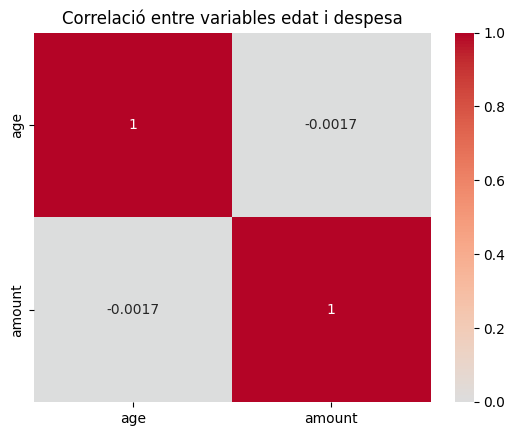

In [ ]:
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0) #Importante centrar en 0 para que los colores tengan sentido
plt.title("Correlació entre variables edat i despesa")
plt.show()

Interpretació: No s’observa cap correlació significativa entre l’edat dels usuaris i l’import de les transaccions, ja que el coeficient és molt proper a zero.

*Nota personal*: la correlació només té sentit entre variables numèriques.

2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

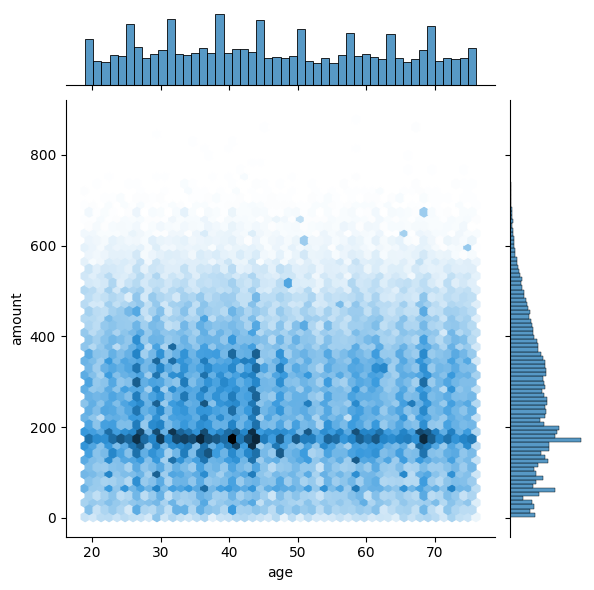

In [ ]:
sns.jointplot(
    x='age',
    y='amount',
    data=df_corr,
    kind='hex'  # mejor con muchos datos
)

Interpretació: El gràfic mostra la relació entre l’edat dels usuaris i l’import de les transaccions. No s’observa una correlació clara entre ambdues variables, ja que la distribució és força homogènia en totes les edats, pot ser una mica més concentrats al voltant del 30-50 anys. No obstant això, es pot detectar una concentració significativa de transaccions en rangs d’import específics, especialment al voltant dels 150-200, així com alguns valors extrems més elevats.

### **Nivell 3**
1. Transfereix totes les visualitzacions del Nivell 1 a Power BI utilitzant scripts de Python.
Recorda: quan carreguis els teus dataframes a Power BI, assegura't d’incloure una columna identificadora o una combinació de columnes que garanteixi la unicitat de cada registre. Per defecte, Power BI elimina duplicats i podries perdre informació.

En el meu cas, l'entorn del meu Visual Studio Code és diferent del de Power BI per treballar en un Mac. Per tant, per questions de temps utilitzaré els csv per carregar les dades al meu Power BI, establint relacions entre elles. En un entorn real, la connexió es realitzaria directament entre Power BI i la base de dades MySQL, evitant la necessitat d'exportar dades a CSV.

In [ ]:
df_user_spending.to_csv("user_spending.csv", index=False)

In [ ]:
df_merge_final.to_csv("merge_final.csv", index=False)